# Notebook 7 — predictive component

Comparing predictive performance of Logistic Regression, Random Forest, and XGBoost on a temporal validation split.

**Steps performed:**
1. Feature sets and temporal split (train: 2019–2021, test: 2022–2024)
2. Logit baseline (no Year FE)
3. Random Forest with hyperparameter tuning
4. XGBoost with hyperparameter tuning
5. Comparison table
6. Feature importance — RF vs XGBoost
7. ROC curves
8. Confusion matrices at optimal threshold

**Main dependent variable:** Y3 — Increasing Credit (`Y3_Increasing_Credit`)  
**Input:** `df_cleaned.csv` from Notebook 6.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats.mstats import winsorize

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    brier_score_loss, roc_curve,
    balanced_accuracy_score, confusion_matrix
)
from xgboost import XGBClassifier

## 0. Loading data and reconstructing variables

In [2]:
df = pd.read_csv('df_with_indicators.csv', sep=';', encoding='utf-8', low_memory=False)
print('Dataset shape:', df.shape)

# Restore Categorical order — ensures drop_first=True removes 'Other' (same as notebook 7)
df['Sector Group'] = pd.Categorical(
    df['Sector Group'],
    categories=['Other', 'Agriculture', 'Manufacturing',
                'Wholesale & Retail Trade', 'Energy', 'Mining'],
    ordered=False
)

Dataset shape: (81062, 54)


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'figure.facecolor': 'white', 'figure.dpi': 150,
    'font.family': 'serif', 'font.serif': ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 11, 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#e0e0e0', 'grid.linewidth': 0.6,
    'savefig.dpi': 300, 'savefig.facecolor': 'white',
})
COLORS = {
    'primary': '#2c5f8a', 'secondary': '#4a9aba', 'positive': '#3ab5a5',
    'negative': '#d9534f', 'neutral': '#95a5a6', 'accent': '#f0c060',
}

In [4]:
SECTOR_MAP = {
    'A': 'Agriculture', 'B': 'Mining', 'C': 'Manufacturing', 'D': 'Energy',
    'E': 'Water & Waste', 'F': 'Construction', 'G': 'Wholesale & Retail Trade',
    'H': 'Transportation', 'I': 'Accommodation & Food', 'J': 'Information & Communication',
    'K': 'Financial Services', 'L': 'Real Estate', 'M': 'Professional Services',
    'N': 'Administrative Services', 'O': 'Public Administration', 'P': 'Education',
    'Q': 'Health & Social Work', 'R': 'Arts & Entertainment', 'S': 'Other Services',
}
TOP_SECTORS    = ['Wholesale & Retail Trade', 'Manufacturing', 'Agriculture', 'Energy', 'Mining']
FRONTLINE_2014 = ['Донецька область', 'Луганська область']
FRONTLINE_2022 = ['Харківська область', 'Запорізька область', 'Херсонська область',
                  'Миколаївська область', 'Чернігівська область', 'Сумська область']
MAIN_DEP_VAR   = 'Y3_Increasing_Credit'

## 1. Feature sets and temporal split

Defining two feature sets: a logit set (A2_ROA all predictors) and a full ML set with sector dummies. Splitting data temporally — training on pre-war years (2019–2021) and testing on the war period (2022–2024).

In [5]:
pred_features_logit = [
    'ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
    'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
    'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1',
    'Frontline_2014', 'Frontline_2022',
]

pred_features_ml = [
    'ROA_w_lag1', 'Equity_Ratio_w_lag1', 'NetDebt_to_EBITDA_w_lag1', 'Firm Age',
    'Quick_Ratio_w_lag1', 'Cash_Ratio_w_lag1', 'Tangibility_w_lag1',
    'Asset_Turnover_w_lag1', 'Inventory_Days_w_lag1', 'AR_Days_w_lag1', 'AP_Days_w_lag1',
    'Frontline_2014', 'Frontline_2022',
]

train_years = [2019, 2020, 2021]
test_years  = [2022, 2023, 2024]

df_train = df[df['Year'].isin(train_years)].copy()
df_test  = df[df['Year'].isin(test_years)].copy()

print('TEMPORAL SPLIT')
print('=' * 55)
print(f'Train (2019-2021): N={len(df_train):,}')
print(f'  Y3=1: {int(df_train[MAIN_DEP_VAR].sum()):,} ({df_train[MAIN_DEP_VAR].mean()*100:.1f}%)')
print(f'Test  (2022-2024): N={len(df_test):,}')
print(f'  Y3=1: {int(df_test[MAIN_DEP_VAR].sum()):,} ({df_test[MAIN_DEP_VAR].mean()*100:.1f}%)')

TEMPORAL SPLIT
Train (2019-2021): N=35,747
  Y3=1: 3,645 (12.9%)
Test  (2022-2024): N=34,427
  Y3=1: 3,894 (12.1%)


In [6]:
# Sector dummies — fit on train, align on test
sect_train = pd.get_dummies(df_train['Sector Group'], prefix='Sector', drop_first=True).astype(float)
df_train   = pd.concat([df_train, sect_train], axis=1).loc[:, lambda d: ~d.columns.duplicated()]

sect_test  = pd.get_dummies(df_test['Sector Group'], prefix='Sector', drop_first=True).astype(float)
df_test    = pd.concat([df_test,  sect_test],  axis=1).loc[:, lambda d: ~d.columns.duplicated()]

sector_cols_ml = list(sect_train.columns)
for col in sector_cols_ml:
    if col not in df_test.columns:
        df_test[col] = 0

pred_features_logit_full = pred_features_logit + sector_cols_ml
pred_features_ml_full    = pred_features_ml    + sector_cols_ml


def prepare_xy(df_split, features, proxy):
    """Drop rows with missing values and return X, y arrays."""
    avail = [f for f in features if f in df_split.columns]
    temp  = df_split[avail + [proxy]].dropna()
    return temp[avail].astype(float), temp[proxy].astype(float)


X_train_logit, y_train_logit = prepare_xy(df_train, pred_features_logit_full, MAIN_DEP_VAR)
X_test_logit,  y_test_logit  = prepare_xy(df_test,  pred_features_logit_full, MAIN_DEP_VAR)
X_train,       y_train       = prepare_xy(df_train, pred_features_ml_full,    MAIN_DEP_VAR)
X_test,        y_test        = prepare_xy(df_test,  pred_features_ml_full,    MAIN_DEP_VAR)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Logit  — Train: N={len(X_train_logit):,}  Test: N={len(X_test_logit):,}')
print(f'RF/XGB — Train: N={len(X_train):,}  Test: N={len(X_test):,}')
print(f'Class ratio (neg/pos): {scale_pos:.2f}')

Logit  — Train: N=22,444  Test: N=23,936
RF/XGB — Train: N=22,444  Test: N=23,936
Class ratio (neg/pos): 5.42


In [7]:
def ks_statistic(y_true, y_prob):
    """Kolmogorov-Smirnov statistic = max(TPR - FPR)."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


def optimal_threshold(y_true, y_prob):
    """Youden's J optimal threshold."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return thresholds[np.argmax(tpr - fpr)]


def evaluate_model(model, X_test, y_test, model_name):
    """Compute full set of evaluation metrics."""
    y_prob     = model.predict_proba(X_test)[:, 1]
    y_pred     = (y_prob >= 0.5).astype(int)
    y_pred_opt = (y_prob >= optimal_threshold(y_test, y_prob)).astype(int)
    return {
        'Model'       : model_name,
        'AUC-ROC'     : roc_auc_score(y_test, y_prob),
        'AUC-PR'      : average_precision_score(y_test, y_prob),
        'F1'          : f1_score(y_test, y_pred, zero_division=0),
        'Precision'   : precision_score(y_test, y_pred, zero_division=0),
        'Recall'      : recall_score(y_test, y_pred, zero_division=0),
        'Balanced Acc': balanced_accuracy_score(y_test, y_pred_opt),
        'Brier'       : brier_score_loss(y_test, y_prob),
    }, y_prob


print('Helper functions defined.')

Helper functions defined.


## 2. Logit Baseline

Fitting logistic regression without Year FE on the training period. Using the A2_ROA predictor set with sector dummies.

In [8]:
print('FITTING LOGIT BASELINE (no Year FE)')
print('=' * 55)

X_train_sm = sm.add_constant(X_train_logit)

logit_train_model = None
for method in ['bfgs', 'lbfgs', 'nm']:
    try:
        logit_train_model = sm.Logit(y_train_logit, X_train_sm).fit(
            method=method, maxiter=1000, disp=False
        )
        print(f'Converged with: {method}')
        break
    except Exception as e:
        print(f'  {method} failed: {str(e)[:50]}')

X_test_sm    = sm.add_constant(X_test_logit).reindex(columns=X_train_sm.columns, fill_value=0)
y_prob_logit = logit_train_model.predict(X_test_sm)


class LogitWrapper:
    """Wrap statsmodels Logit to match sklearn predict_proba interface."""
    def __init__(self, model, cols):
        self.model = model
        self.cols  = cols
    def predict_proba(self, X):
        X_sm = sm.add_constant(X.astype(float)).reindex(columns=self.cols, fill_value=0)
        p    = self.model.predict(X_sm)
        return np.column_stack([1 - p, p])


logit_wrapper            = LogitWrapper(logit_train_model, X_train_sm.columns)
logit_metrics, _         = evaluate_model(logit_wrapper, X_test_logit, y_test_logit, 'Logit (Final)')
logit_metrics['AUC-ROC'] = roc_auc_score(y_test_logit, y_prob_logit)
logit_metrics['Brier']   = brier_score_loss(y_test_logit, y_prob_logit)

mcf_train = 1 - logit_train_model.llf / logit_train_model.llnull
print(f'Train McFadden R2: {mcf_train:.4f}')
print(f'Test  AUC-ROC:     {logit_metrics["AUC-ROC"]:.4f}')
print(f'Test  Brier:       {logit_metrics["Brier"]:.4f}')

FITTING LOGIT BASELINE (no Year FE)
Converged with: bfgs
Train McFadden R2: 0.1370
Test  AUC-ROC:     0.7778
Test  Brier:       0.1167


## 3. Random Forest

Fitting Random Forest with randomized hyperparameter search (5-fold stratified CV, 30 iterations). Using `class_weight='balanced'` to handle class imbalance.

In [9]:
print('FITTING RANDOM FOREST')
print('=' * 55)

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist_rf = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 5, 7, 10, None],
    'min_samples_leaf': [10, 20, 50, 100],
    'max_features'    : ['sqrt', 'log2', 0.3],
    'max_samples'     : [0.7, 0.8, 0.9, None],
}

rf_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions = param_dist_rf,
    n_iter=30, scoring='roc_auc',
    cv=cv_inner, random_state=42, n_jobs=-1, verbose=0,
)
print('Running RandomizedSearchCV (n_iter=30, cv=5)...')
rf_search.fit(X_train, y_train)
print(f'Best params: {rf_search.best_params_}')
print(f'Best CV AUC: {rf_search.best_score_:.4f}')

rf_best = rf_search.best_estimator_
rf_metrics, y_prob_rf = evaluate_model(rf_best, X_test, y_test, 'Random Forest')
print(f'Test AUC-ROC: {rf_metrics["AUC-ROC"]:.4f}')
print(f'Test Brier:   {rf_metrics["Brier"]:.4f}')

FITTING RANDOM FOREST
Running RandomizedSearchCV (n_iter=30, cv=5)...
Best params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': None}
Best CV AUC: 0.8194
Test AUC-ROC: 0.8315
Test Brier:   0.1318


In [10]:
fi_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_best.feature_importances_})
fi_rf['Feature'] = (fi_rf['Feature']
                    .str.replace('_w_lag1', '').str.replace('_lag1', '').str.replace('Sector_', ''))
fi_rf = fi_rf.sort_values('Importance', ascending=False)

print('FEATURE IMPORTANCE — Random Forest (top 10):')
print(fi_rf.head(10).to_string(index=False))

FEATURE IMPORTANCE — Random Forest (top 10):
          Feature  Importance
NetDebt_to_EBITDA    0.306785
       Cash_Ratio    0.097114
              ROA    0.091255
   Inventory_Days    0.072699
     Equity_Ratio    0.068670
          AP_Days    0.068392
   Asset_Turnover    0.067337
          AR_Days    0.056862
      Quick_Ratio    0.055883
      Tangibility    0.052864


## 4. XGBoost

Fitting XGBoost with randomized hyperparameter search. Using `scale_pos_weight` to handle class imbalance.

In [11]:
print('FITTING XGBOOST')
print('=' * 55)
print(f'scale_pos_weight = {scale_pos:.2f}')

param_dist_xgb = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [5, 10, 20, 50],
    'gamma'           : [0, 0.1, 0.3, 0.5],
}

xgb_search = RandomizedSearchCV(
    estimator           = XGBClassifier(scale_pos_weight=scale_pos, random_state=42,
                                        n_jobs=-1, eval_metric='auc', verbosity=0),
    param_distributions = param_dist_xgb,
    n_iter=30, scoring='roc_auc',
    cv=cv_inner, random_state=42, n_jobs=-1, verbose=0,
)
print('Running RandomizedSearchCV (n_iter=30, cv=5)...')
xgb_search.fit(X_train, y_train)
print(f'Best params: {xgb_search.best_params_}')
print(f'Best CV AUC: {xgb_search.best_score_:.4f}')

xgb_best = xgb_search.best_estimator_
xgb_metrics, y_prob_xgb = evaluate_model(xgb_best, X_test, y_test, 'XGBoost')
print(f'Test AUC-ROC: {xgb_metrics["AUC-ROC"]:.4f}')
print(f'Test Brier:   {xgb_metrics["Brier"]:.4f}')

FITTING XGBOOST
scale_pos_weight = 5.42
Running RandomizedSearchCV (n_iter=30, cv=5)...
Best params: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 50, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV AUC: 0.8200
Test AUC-ROC: 0.8342
Test Brier:   0.1670


In [12]:
fi_xgb = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_best.feature_importances_})
fi_xgb['Feature'] = (fi_xgb['Feature']
                     .str.replace('_w_lag1', '').str.replace('_lag1', '').str.replace('Sector_', ''))
fi_xgb = fi_xgb.sort_values('Importance', ascending=False)

print('FEATURE IMPORTANCE — XGBoost (top 10):')
print(fi_xgb.head(10).to_string(index=False))

FEATURE IMPORTANCE — XGBoost (top 10):
                 Feature  Importance
       NetDebt_to_EBITDA    0.387642
              Cash_Ratio    0.075889
                     ROA    0.064549
             Agriculture    0.051774
Wholesale & Retail Trade    0.046313
            Equity_Ratio    0.043830
          Inventory_Days    0.041390
          Asset_Turnover    0.038981
                 AP_Days    0.038625
           Manufacturing    0.035718


## 5. Comparison table

In [13]:
print('FINAL COMPARISON: Logit vs RF vs XGBoost')
print('(Test set: 2022-2024)')
print('=' * 70)

all_metrics  = [logit_metrics, rf_metrics, xgb_metrics]
model_labels = ['Logit', 'RF', 'XGBoost']

print(f"{'Metric':<20}" + ''.join(f"{m['Model']:>16}" for m in all_metrics) + f"{'Best':>12}")
print('-' * 70)

for metric in ['AUC-ROC', 'AUC-PR', 'F1', 'Precision', 'Recall', 'Balanced Acc', 'Brier']:
    vals     = [m[metric] for m in all_metrics]
    best_idx = np.argmin(vals) if metric == 'Brier' else np.argmax(vals)
    print(f"{metric:<20}" + ''.join(f"{v:>16.4f}" for v in vals) + f"{model_labels[best_idx]:>12}")

print('=' * 70)
print('Train: 2019-2021 | Test: 2022-2024')
print('Logit: A2_ROA feature set, no Year FE, bfgs')
print(f'RF: class_weight=balanced, full A2_ROA feature set')
print(f'XGBoost: scale_pos_weight={scale_pos:.2f}, full A2_ROA feature set')
print("Balanced Acc: at optimal threshold (Youden's J)")
print('Brier: lower is better')

FINAL COMPARISON: Logit vs RF vs XGBoost
(Test set: 2022-2024)
Metric                 Logit (Final)   Random Forest         XGBoost        Best
----------------------------------------------------------------------
AUC-ROC                       0.7778          0.8315          0.8342     XGBoost
AUC-PR                        0.3594          0.4307          0.4372     XGBoost
F1                            0.1756          0.5112          0.5106          RF
Precision                     0.3767          0.4238          0.3852          RF
Recall                        0.1145          0.6440          0.7571     XGBoost
Balanced Acc                  0.7321          0.7708          0.7681          RF
Brier                         0.1167          0.1318          0.1670       Logit
Train: 2019-2021 | Test: 2022-2024
Logit: A2_ROA feature set, no Year FE, bfgs
RF: class_weight=balanced, full A2_ROA feature set
XGBoost: scale_pos_weight=5.42, full A2_ROA feature set
Balanced Acc: at optimal thresho

## 6. Feature importance — RF vs XGBoost

In [14]:
print('FEATURE IMPORTANCE COMPARISON — RF vs XGBoost')
print('=' * 60)
fi_compare = fi_rf.merge(fi_xgb, on='Feature', suffixes=('_RF', '_XGB')).sort_values('Importance_RF', ascending=False)
print(f"{'Feature':<30} {'RF':>12} {'XGBoost':>12}")
print('-' * 55)
for _, row in fi_compare.iterrows():
    print(f"{row['Feature']:<30} {row['Importance_RF']:>12.4f} {row['Importance_XGB']:>12.4f}")

FEATURE IMPORTANCE COMPARISON — RF vs XGBoost
Feature                                  RF      XGBoost
-------------------------------------------------------
NetDebt_to_EBITDA                    0.3068       0.3876
Cash_Ratio                           0.0971       0.0759
ROA                                  0.0913       0.0645
Inventory_Days                       0.0727       0.0414
Equity_Ratio                         0.0687       0.0438
AP_Days                              0.0684       0.0386
Asset_Turnover                       0.0673       0.0390
AR_Days                              0.0569       0.0284
Quick_Ratio                          0.0559       0.0235
Tangibility                          0.0529       0.0232
Firm Age                             0.0370       0.0245
Agriculture                          0.0102       0.0518
Manufacturing                        0.0068       0.0357
Wholesale & Retail Trade             0.0061       0.0463
Energy                               0.0010

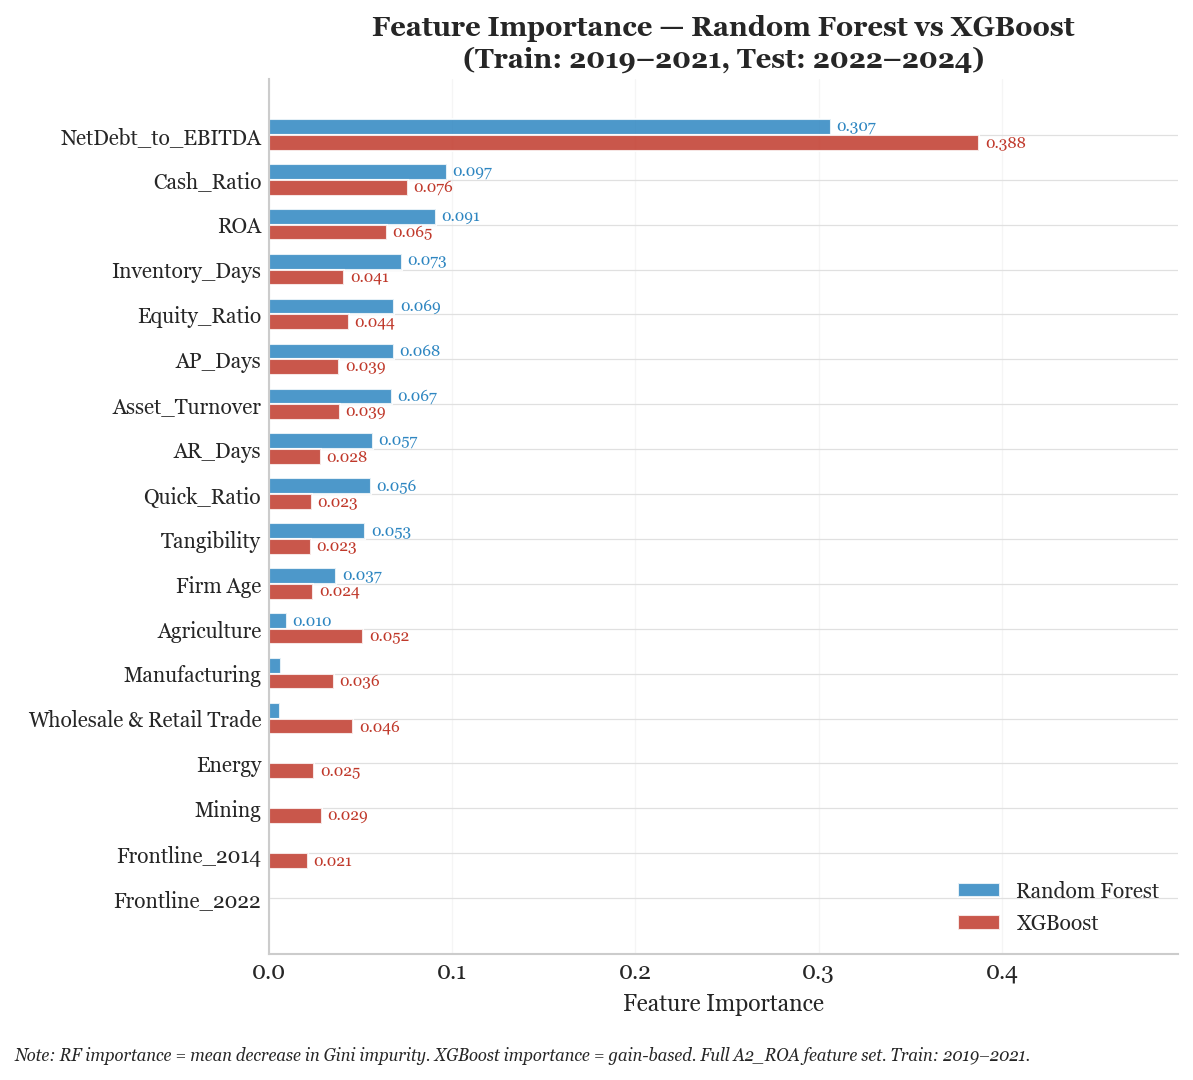

Saved: feature_importance_rf_xgb.png


In [15]:
fi_plot  = fi_compare.sort_values('Importance_RF', ascending=True)
features = fi_plot['Feature'].tolist()
imp_rf   = fi_plot['Importance_RF'].tolist()
imp_xgb  = fi_plot['Importance_XGB'].tolist()
y_pos    = np.arange(len(features))
height   = 0.35

fig, ax = plt.subplots(figsize=(8, 7))

bars_rf  = ax.barh(y_pos + height/2, imp_rf,  height, color='#2e86c1',
                   alpha=0.85, label='Random Forest', edgecolor='white')
bars_xgb = ax.barh(y_pos - height/2, imp_xgb, height, color='#c0392b',
                   alpha=0.85, label='XGBoost',       edgecolor='white')

for bar, val in zip(bars_rf, imp_rf):
    if val > 0.01:
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7.5, color='#2e86c1')
for bar, val in zip(bars_xgb, imp_xgb):
    if val > 0.01:
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7.5, color='#c0392b')

ax.set_yticks(y_pos)
ax.set_yticklabels(features, fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Feature Importance — Random Forest vs XGBoost\n'
             '(Train: 2019\u20132021, Test: 2022\u20132024)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(max(imp_rf), max(imp_xgb)) * 1.28)

fig.text(0.01, -0.02,
         'Note: RF importance = mean decrease in Gini impurity. '
         'XGBoost importance = gain-based. '
         'Full A2_ROA feature set. Train: 2019\u20132021.',
         fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('feature_importance_rf_xgb.png', dpi=150)
plt.show()
print('Saved: feature_importance_rf_xgb.png')

## 7. ROC Curves

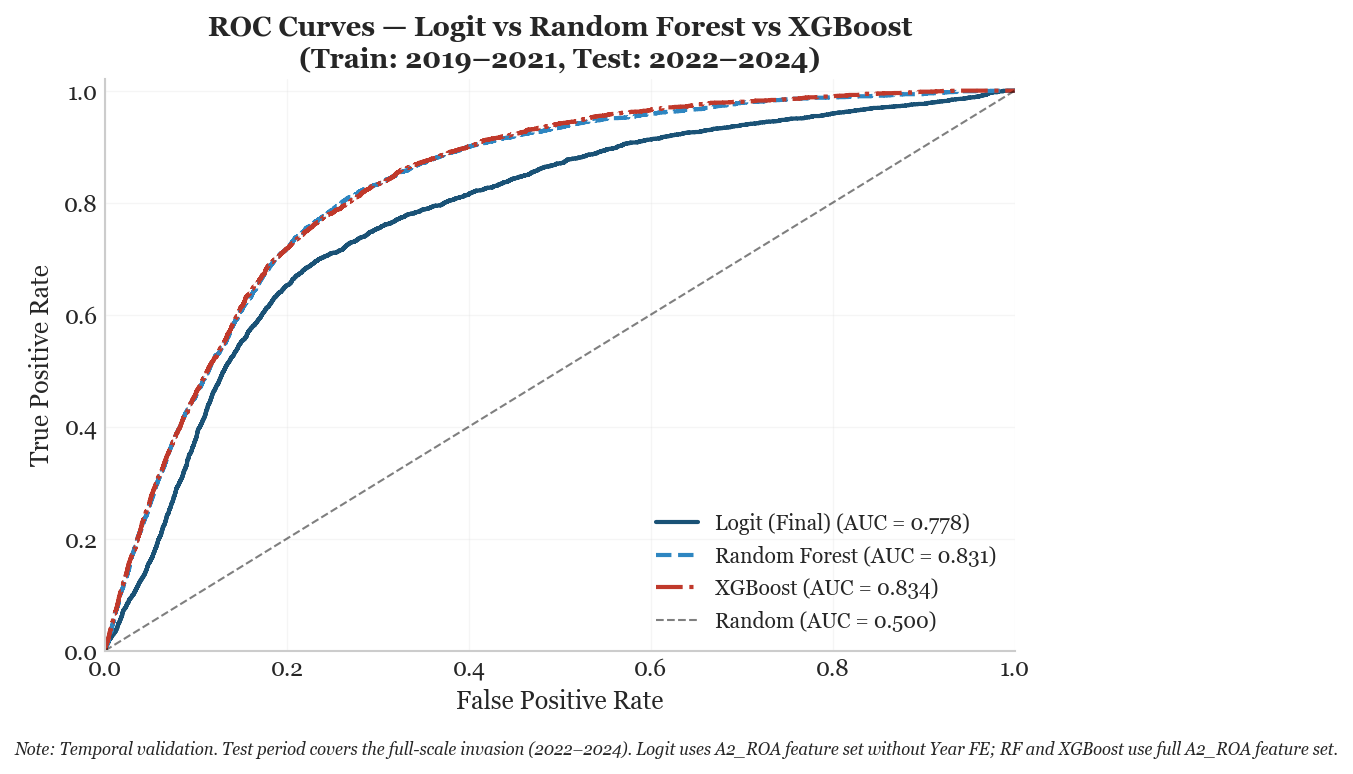

Saved: roc_curves_comparison.png


In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_true, y_prob, color, ls in [
    ('Logit (Final)', y_test_logit, y_prob_logit, '#1a5276', '-'),
    ('Random Forest', y_test,       y_prob_rf,    '#2e86c1', '--'),
    ('XGBoost',       y_test,       y_prob_xgb,   '#c0392b', '-.'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val     = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
            label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves \u2014 Logit vs Random Forest vs XGBoost\n'
             '(Train: 2019\u20132021, Test: 2022\u20132024)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

fig.text(0.01, -0.02,
         'Note: Temporal validation. Test period covers the full-scale '
         'invasion (2022\u20132024). Logit uses A2_ROA feature set without Year FE; '
         'RF and XGBoost use full A2_ROA feature set.',
         fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150)
plt.show()
print('Saved: roc_curves_comparison.png')

## 8. Confusion matrices at optimal threshold

Computing confusion matrices at the Youden's J optimal threshold for each model.

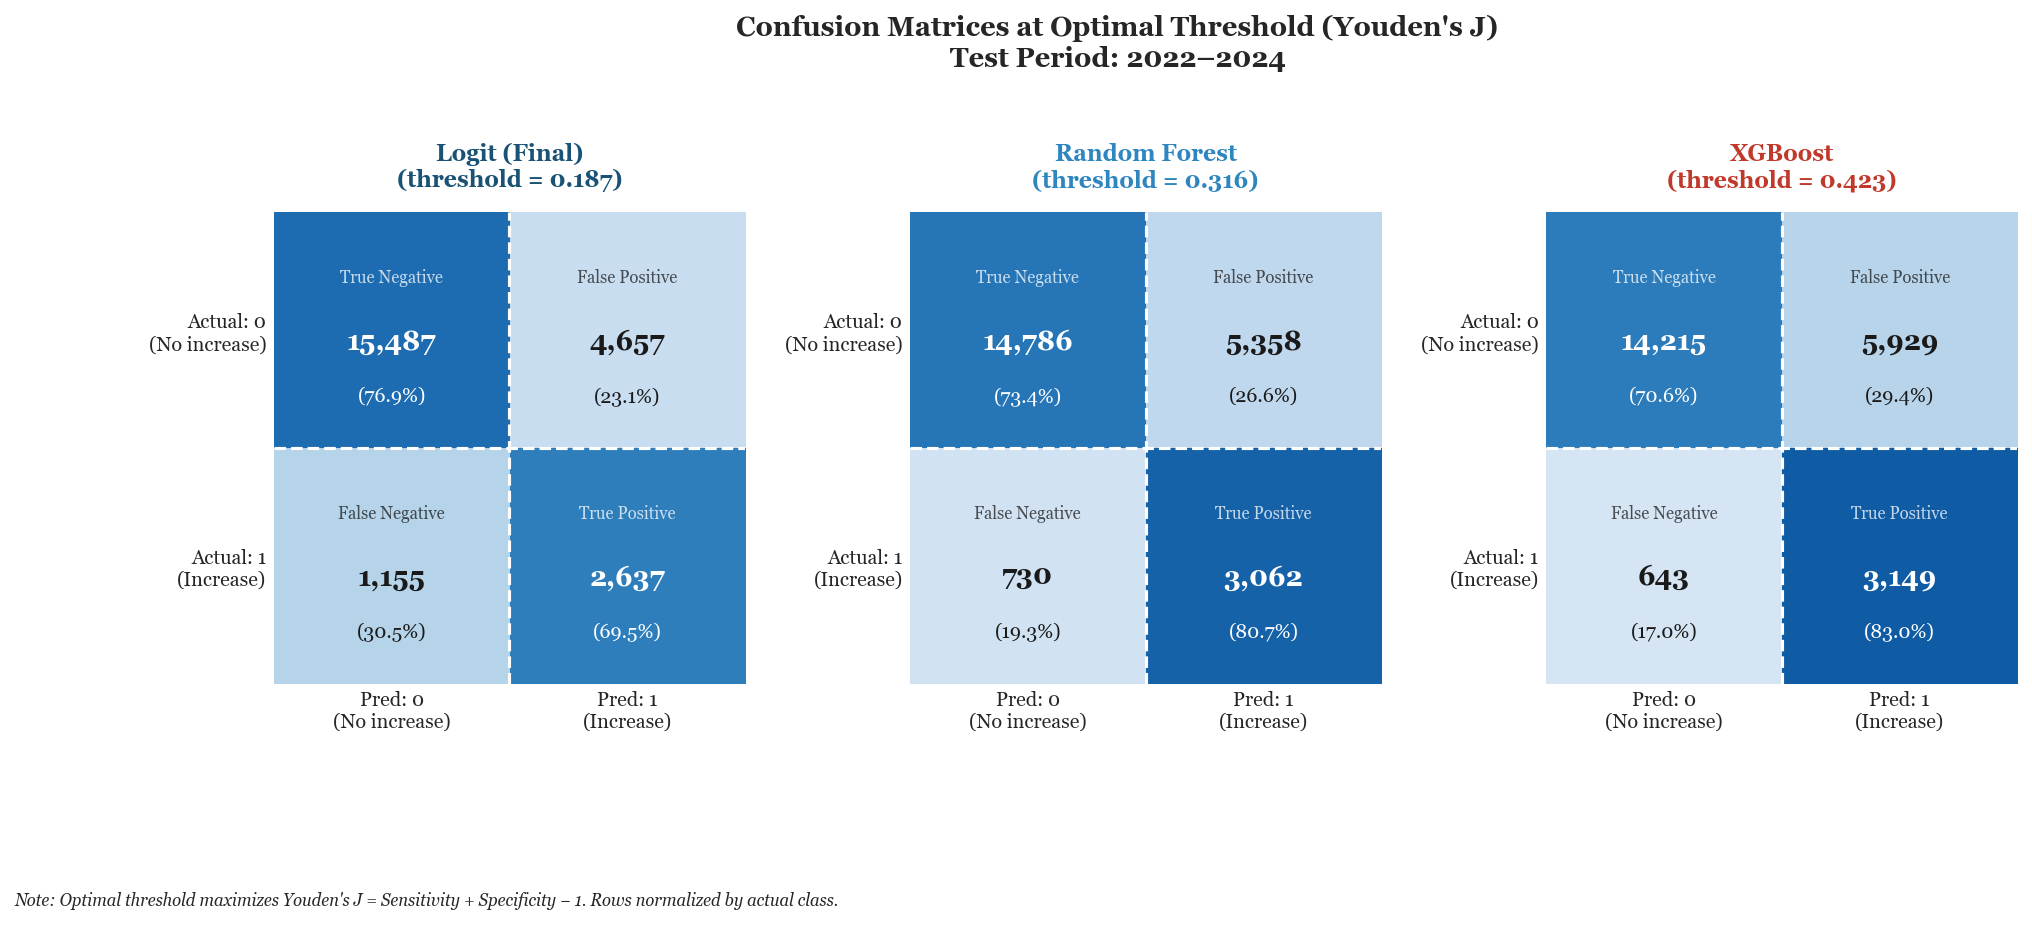

Saved: confusion_matrices.png


In [17]:
thresh_logit = optimal_threshold(y_test_logit, y_prob_logit)
thresh_rf    = optimal_threshold(y_test,        y_prob_rf)
thresh_xgb   = optimal_threshold(y_test,        y_prob_xgb)

cm_logit = confusion_matrix(y_test_logit, (y_prob_logit >= thresh_logit).astype(int))
cm_rf    = confusion_matrix(y_test,       (y_prob_rf    >= thresh_rf).astype(int))
cm_xgb   = confusion_matrix(y_test,       (y_prob_xgb   >= thresh_xgb).astype(int))

models_cm   = [
    ('Logit (Final)', cm_logit, thresh_logit, '#1a5276'),
    ('Random Forest', cm_rf,    thresh_rf,    '#2e86c1'),
    ('XGBoost',       cm_xgb,   thresh_xgb,   '#c0392b'),
]
cell_labels = [['True Negative', 'False Positive'],
               ['False Negative', 'True Positive']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), gridspec_kw={'wspace': 0.35})

for ax, (name, cm, thresh, color) in zip(axes, models_cm):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='equal')
    ax.grid(False)
    ax.axhline(0.5, color='white', linewidth=1.5, linestyle='--', zorder=4)
    ax.axvline(0.5, color='white', linewidth=1.5, linestyle='--', zorder=4)

    for i in range(2):
        for j in range(2):
            count   = cm[i, j]
            pct     = cm_norm[i, j] * 100
            txt_col = 'white' if cm_norm[i, j] > 0.45 else '#1a1a1a'
            ax.text(j, i - 0.22, cell_labels[i][j], ha='center', va='center',
                    fontsize=8, color=txt_col, alpha=0.75)
            ax.text(j, i + 0.05, f'{count:,}', ha='center', va='center',
                    fontsize=13, color=txt_col, fontweight='bold')
            ax.text(j, i + 0.28, f'({pct:.1f}%)', ha='center', va='center',
                    fontsize=9.5, color=txt_col)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: 0\n(No increase)', 'Pred: 1\n(Increase)'], fontsize=9.5)
    ax.set_yticklabels(['Actual: 0\n(No increase)', 'Actual: 1\n(Increase)'], fontsize=9.5)
    ax.tick_params(which='both', length=0)
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_title(f'{name}\n(threshold = {thresh:.3f})',
                 fontsize=11, fontweight='bold', color=color, pad=12)

fig.suptitle("Confusion Matrices at Optimal Threshold (Youden's J)\nTest Period: 2022\u20132024",
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.01, -0.06,
         "Note: Optimal threshold maximizes Youden's J = Sensitivity + Specificity \u2212 1. "
         "Rows normalized by actual class.",
         fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print('Saved: confusion_matrices.png')